findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

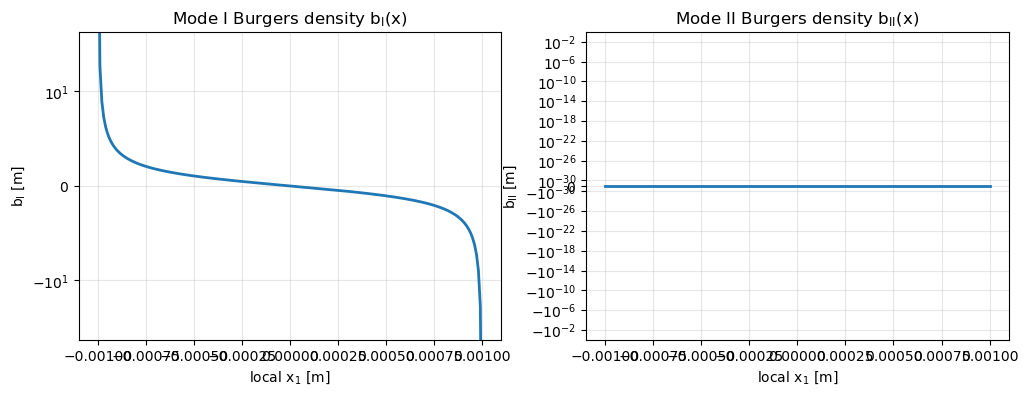

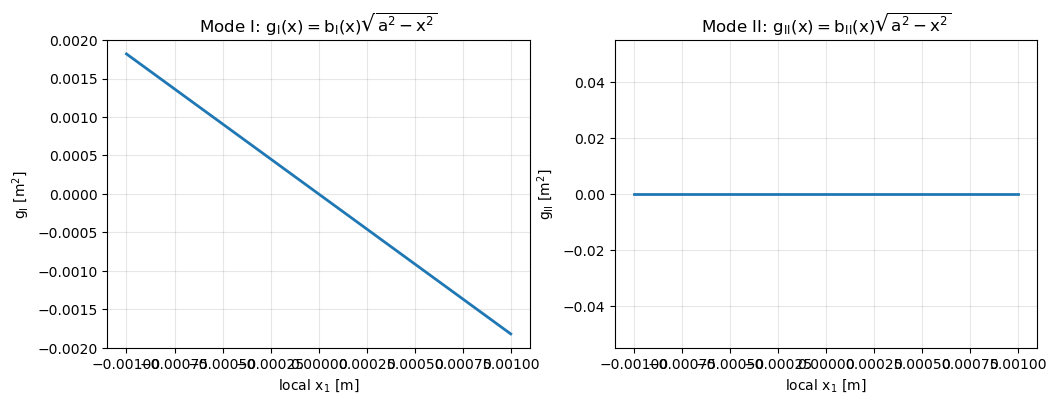

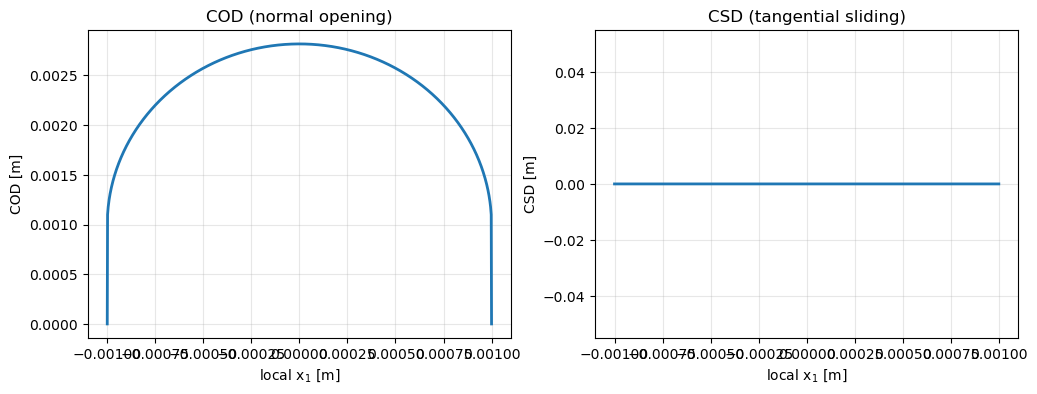

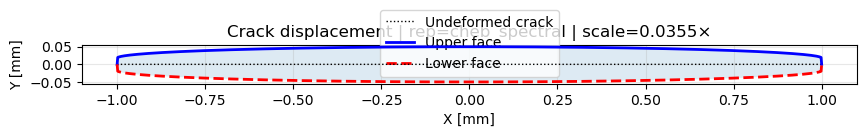

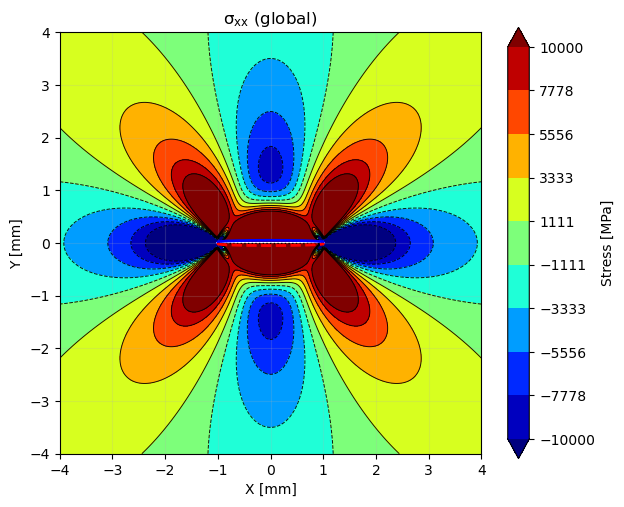

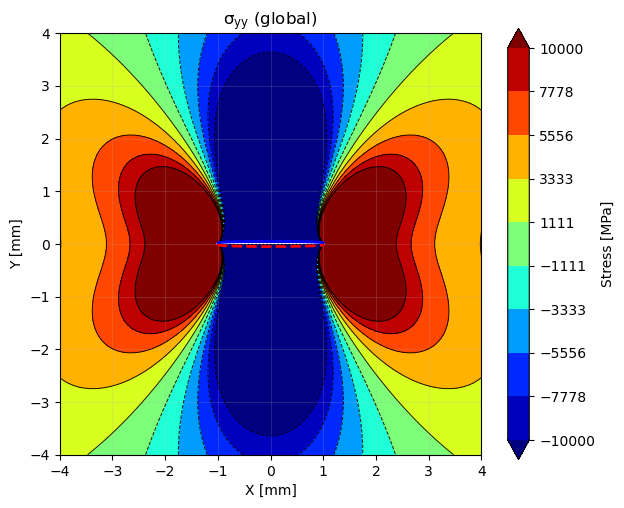

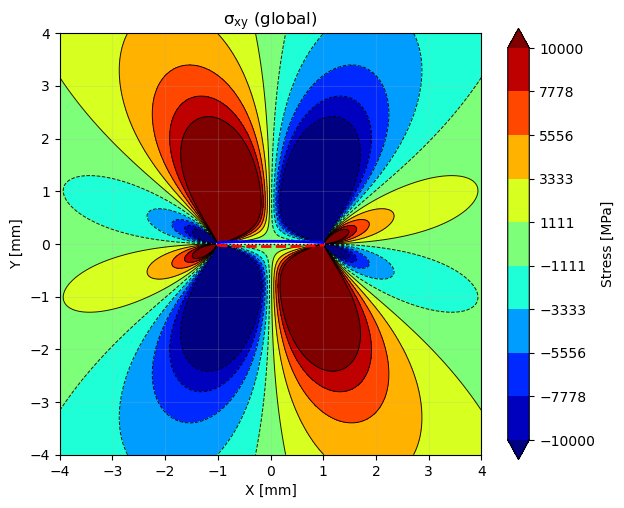

In [1]:
"""
DCE Analysis - Jupyter Notebook (clean v0)
"""

import numpy as np
import matplotlib.pyplot as plt
import os, sys

# Ensure repo root is on sys.path (so "utils" imports resolve)
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)

from utils.dce_calcs_v0 import Material, Crack, AppliedStress, DCESingleCrackStatic
from utils.dce_plots_v0 import DCEPlotterV0

# Inputs
ne_half = 10
theta  = np.deg2rad(0.0)
stress = AppliedStress(sigma_xx=0.0, sigma_yy=100e6, sigma_xy=0.0)   # GLOBAL

material = Material(E=200e9, nu=0.30, plane_stress=False)
crack    = Crack(length=2e-3, angle=theta, center=(0.0, 0.0))        # 2a [m]

calc = DCESingleCrackStatic(material, crack, stress)

# Solve (choose one)
import utils.dce_calcs_v0 as dms
"""
res= calc.solve(
    ne_half=ne_half,
    representation="delta_collocation",
    nq_src=2,     # DOFs per element
    nq_col=4,     # oversampled traction equations per element
    ridge=1e-14   # tiny ridge (optional, but helps conditioning)
)
"""
# res = calc.solve(ne_half=ne_half, representation="cheb_quad")
res = calc.solve(ne_half=ne_half, representation="cheb_spectral")

# Plots
plotter = DCEPlotterV0(calc, res)

# Robust b(x) plots + also show g(x)=b(x)*sqrt(a^2-x^2)
plotter.plot_burgers(
    n=200,
    yscale="symlog",          # handles tip blow-up visually
    clip_percentile=99.0,     # prevents a few extreme samples from setting the y-limits
    show_g=True               # second figure: g(x) is usually the cleanest diagnostic
)

plotter.plot_cod_csd()
plotter.plot_crack_displacement_geometry()


plotter = DCEPlotterV0(calc, res)

figs = plotter.plot_stress_field_components(
    coords="global",
    component_set="global",     # or "both"
    extent_factor=4.0,
    n_grid=401,
    cmap="jet",
    n_bands=10,
    label_contours=False,
    add_remote=True,

    # Range control:
    vmax_factor=5.0,           # 10× remote component
    vref_component="syy",       # use remote σyy as the reference
    symmetric=True,             # ±vmax
    vmax_mpa=10000,   # Optional explicit axis limits (meters):
    # xlim=(-2.5e-3, 2.5e-3),
    # ylim=(-1.5e-3, 1.5e-3),
)
plt.show()

